# Part 1: Distributed Data Processing with Spark

## Task 1.1: Spark Environment Setup & Data Loading 

First we initialize a SparkSession that utilizes all available CPU cores for parallel processing and allocates 6GB of RAM to the driver process 

In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
.master('local[*]') \
.appName('COMP3610A3') \
.config('spark.sql.adaptive.enabled', 'true') \
.config('spark.driver.memory', '6g') \
.getOrCreate()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/31 22:23:04 WARN Utils: Your hostname, Augusts-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.100.228 instead (on interface en0)
26/03/31 22:23:04 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/31 22:23:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Here we verify the Spark session and print key details like version, app name, master, parallelism, and memory/core configurations for debugging and monitoring.


In [2]:
# Verify the session
print(f'Spark version: {spark.version}')
print(f'App name: {spark.sparkContext.appName}')
print(f'Master: {spark.sparkContext.master}')
print(f'Default parallelism: {spark.sparkContext.defaultParallelism}')
print(f'Spark UI: http://localhost:4040')
print(f'Number of executor cores: {spark.sparkContext.defaultParallelism}')
# List available configurations
for key, value in sorted(spark.sparkContext.getConf().getAll()):
    if 'memory' in key.lower() or 'core' in key.lower() or 'master' in key.lower():
        print(f' {key} = {value}')

Spark version: 4.1.1
App name: COMP3610A3
Master: local[*]
Default parallelism: 8
Spark UI: http://localhost:4040
Number of executor cores: 8
 spark.driver.memory = 6g
 spark.master = local[*]


Here we create a data folder if needed, download the NYC Taxi Parquet file only if it doesn’t exist, and then load it into a Spark DataFrame.


In [3]:
import urllib.request, os
os.makedirs('data', exist_ok=True)
url = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet'
output = 'data/yellow_tripdata_2024-01.parquet'
if not os.path.exists(output):
    print('Downloading NYC Taxi data...')
    urllib.request.urlretrieve(url, output)
    print(f'Downloaded: {os.path.getsize(output) / 1e6:.1f} MB')
else:
    print(f'File already exists: {os.path.getsize(output) / 1e6:.1f} MB')

taxi = spark.read.parquet(output)

File already exists: 50.0 MB


In [67]:
taxi.show(5,True)
taxi.printSchema()
print(f'Number of rows: {taxi.count():,}')
print(f'Number of columns: {len(taxi.columns)}')
print(f'Number of partitions: {taxi.rdd.getNumPartitions()}')

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       2| 2024-01-01 00:57:55|  2024-01-01 01:17:43|              1|         1.72|         1|                 N|         186|          79|           2|       17.7|  1.0|    0.5|       0.

Here we measure and compare the time it takes to read the Parquet file with Spark (lazy vs full count) and Pandas, reporting row counts and memory usage.


In [6]:
import time
import pandas as pd

start = time.time()
df_spark = spark.read.parquet('data/yellow_tripdata_2024-01.parquet')
spark_read_time = time.time() - start
# Time Spark action (forces full read)
start = time.time()
spark_count = df_spark.count()
spark_action_time = time.time() - start
# Time Pandas read
start = time.time()
df_pandas = pd.read_parquet('data/yellow_tripdata_2024-01.parquet')
pandas_read_time = time.time() - start
print(f'Spark schema read: {spark_read_time:.3f}s (lazy - no data loaded)')
print(f'Spark count action: {spark_action_time:.3f}s ({spark_count:,} rows)')
print(f'Pandas full read: {pandas_read_time:.3f}s ({len(df_pandas):,} rows)')
print(f'Pandas memory usage: {df_pandas.memory_usage(deep=True).sum() / 1e6:.1f}MB')
# Clean up Pandas DataFrame to free memory
del df_pandas

Spark schema read: 0.050s (lazy - no data loaded)
Spark count action: 0.067s (2,964,624 rows)
Pandas full read: 0.398s (2,964,624 rows)
Pandas memory usage: 418.0MB


These results show that Spark reads the schema almost instantly (0.050 s) and counts all 2,964,624 rows very quickly (0.067 s), while Pandas fully reads the file slower (0.398 s) and uses much more memory (418.0 MB)


## Task 1.2: Data Cleaning & Feature Engineering in Spark

In [68]:
from pyspark.sql import functions as F

critical_cols =['tpep_pickup_datetime','tpep_dropoff_datetime','trip_distance','PULocationID','DOLocationID','fare_amount','tip_amount','total_amount']

total_rows = taxi.count()

#Remove Null rows
taxi_clean = taxi.dropna(subset=critical_cols)
null_rows = total_rows - taxi_clean.count()

#Filter Out Invalid Trips
taxi_clean = taxi_clean.filter(
    (F.col('trip_distance') > 0) &
    (F.col('fare_amount') > 0) &
    (F.col('fare_amount') <= 500) &
    (F.col('total_amount') > 0) &
    (F.col('tpep_pickup_datetime') < F.col('tpep_dropoff_datetime') )
)

invalid_rows = total_rows - null_rows - taxi_clean.count()

print("Initial rows:", total_rows)
print("Remaining rows:", taxi_clean.count())
print("Rows removed due to null values:", null_rows)
print("Rows removed due to invalid values:", invalid_rows)

Initial rows: 2964624
Remaining rows: 2869572
Rows removed due to null values: 0
Rows removed due to invalid values: 95052


The dataset initally had 2,964,624 rows. No rows were removed for null values, but 95,052 rows were removed for invalid values

Here we create new columns in the cleaned taxi DataFrame to calculate trip duration in minutes, pickup hour, day of week, tip percentage, and trip speed in mph.

In [9]:
taxi_enriched = taxi_clean.withColumns({

'trip_duration_minutes': (F.unix_timestamp('tpep_dropoff_datetime') - F.unix_timestamp('tpep_pickup_datetime')) / 60,

'pickup_hour': F.hour('tpep_pickup_datetime'),

'pickup_day_of_week': F.dayofweek('tpep_pickup_datetime'),

'tip_percentage': F.when(
    F.col('fare_amount') > 0,
    F.col('tip_amount') / F.col('fare_amount') * 100
).otherwise(0),
}).withColumns({
    'trip_speed_mph': F.when(
    F.col('trip_duration_minutes') > 0,
    F.col('trip_distance') / 
    (F.col('trip_duration_minutes') / 60)).otherwise(0),
    })

## Task 1.3: Spark SQL Analytics 


Here we create a temporary view trips from the enriched DataFrame and run SQL queries to analyze it: one to find the top 10 busiest pickup locations with counts, average fare, and average distance, and another to identify the day of the week with the highest average trip speed along with average distance and duration.


In [10]:
taxi_enriched.createOrReplaceTempView('trips')

#Top 10 busiest pickup locations
busiest_locations = spark.sql('''
    SELECT PULocationID,
    COUNT(*) AS num_trips,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(trip_distance), 2) AS avg_distance
    FROM trips
    GROUP BY PULocationID
    ORDER BY num_trips DESC
    LIMIT 10
''')
#daty of week with highest average trip speed
high_avg_speed = spark.sql('''
 SELECT 
        date_format(tpep_pickup_datetime, 'EEEE') AS day_name,
        ROUND(AVG(trip_speed_mph), 2) AS avg_speed_mph,
        ROUND(AVG(trip_distance), 2) AS avg_distance,
        ROUND(AVG(trip_duration_minutes), 2) AS avg_duration_min
    FROM trips
        GROUP BY date_format(tpep_pickup_datetime, 'EEEE')
        ORDER BY avg_speed_mph DESC
        LIMIT 1

''')

In [11]:
print('Top 10 Busiest Pickup Locations:')
busiest_locations.show()
high_avg_speed.show()

Top 10 Busiest Pickup Locations:
+------------+---------+--------+------------+
|PULocationID|num_trips|avg_fare|avg_distance|
+------------+---------+--------+------------+
|         161|   140141|    15.5|         2.6|
|         237|   140118|   12.38|        1.72|
|         132|   138427|   62.79|       15.93|
|         236|   133962|   12.86|        1.87|
|         162|   104342|   15.07|        2.26|
|         230|   102958|    17.9|        2.97|
|         186|   102152|   16.09|         2.3|
|         142|   101794|   13.62|        2.12|
|         138|    87693|   42.33|        9.71|
|         239|    86466|   13.61|        2.29|
+------------+---------+--------+------------+



+--------+-------------+------------+----------------+
|day_name|avg_speed_mph|avg_distance|avg_duration_min|
+--------+-------------+------------+----------------+
| Tuesday|        17.35|        4.25|           16.17|
+--------+-------------+------------+----------------+



The Top 10 busiest pickup locations show that Location 161 and 237 have the highest number of trips, around 140,000 each, indicating they are major hubs for taxi activity. M
ost of these top locations have relatively short average distances (around 1.7–3 miles) and moderate fares ($12–$18), suggesting these trips are frequent, short rides typical of dense urban areas. However, some locations like 132 and 138 have much higher average fares and longer distances, indicating fewer but longer, more expensive trips.

The second query shows that Tuesday has the highest average trip speed at 17.35 mph, with trips averaging 4.25 miles and lasting about 16 minutes. This suggests that traffic conditions or passenger patterns on Tuesdays allow for slightly faster trips compared to other days of the week.
_____

We first identify the top 5 pickup locations by counting trips per location and selecting the highest counts. Then, we calculate total revenue per day for these top locations by grouping by weekday and location and summing the total_amount. Using a window function partitioned by day and ordered by revenue, we rank each location within its day. Numeric weekdays are converted to names, and the final table displays the day, rank, location ID, and total revenue, ordered by day and rank. 

In [12]:
from pyspark.sql.window import Window

# Step 1: Find the top 5 pickup locations overall
top_5_locations = [row.PULocationID for row in 
    taxi_enriched.groupBy('PULocationID')
    .count()
    .orderBy(F.desc('count'))
    .limit(5)
    .collect()]

# Step 2: Get total revenue per location per day (only for top 5)
revenue_by_day = taxi_enriched \
    .filter(F.col('PULocationID').isin(top_5_locations)) \
    .groupBy('pickup_day_of_week', 'PULocationID') \
    .agg(F.sum('total_amount').alias('total_revenue'))

# Step 3: Rank by revenue within each day
day_window = Window.partitionBy('pickup_day_of_week').orderBy(F.desc('total_revenue'))

ranked_revenue = revenue_by_day \
    .withColumn('revenue_rank', F.rank().over(day_window)) \
    .withColumn('day_name', F.when(F.col('pickup_day_of_week') == 1, 'Sunday')
        .when(F.col('pickup_day_of_week') == 2, 'Monday')
        .when(F.col('pickup_day_of_week') == 3, 'Tuesday')
        .when(F.col('pickup_day_of_week') == 4, 'Wednesday')
        .when(F.col('pickup_day_of_week') == 5, 'Thursday')
        .when(F.col('pickup_day_of_week') == 6, 'Friday')
        .when(F.col('pickup_day_of_week') == 7, 'Saturday')) \
    .select('day_name', 'revenue_rank', 'PULocationID', F.round('total_revenue', 2).alias('total_revenue')) \
    .orderBy('pickup_day_of_week', 'revenue_rank')

ranked_revenue.show(35)


+---------+------------+------------+-------------+
| day_name|revenue_rank|PULocationID|total_revenue|
+---------+------------+------------+-------------+
|   Sunday|           1|         132|   1564244.23|
|   Sunday|           2|         161|    249524.25|
|   Sunday|           3|         236|    223270.64|
|   Sunday|           4|         237|    215561.28|
|   Sunday|           5|         162|    188082.18|
|   Monday|           1|         132|   2054604.73|
|   Monday|           2|         161|    460144.28|
|   Monday|           3|         236|    373005.39|
|   Monday|           4|         237|    372575.48|
|   Monday|           5|         162|    334973.93|
|  Tuesday|           1|         132|   1794982.81|
|  Tuesday|           2|         161|     622561.8|
|  Tuesday|           3|         237|    492951.97|
|  Tuesday|           4|         236|    485599.72|
|  Tuesday|           5|         162|    462120.27|
|Wednesday|           1|         132|   1677828.52|
|Wednesday| 

The table shows the top 5 revenue-generating pickup locations for each day of the week. Location 132 consistently earns the most revenue every day, with totals ranging from about $1.28M on Saturday to over $2M on Monday, indicating it is the most profitable pickup area. Locations 161, 236, 237, and 162 follow in ranking, with significantly lower revenue than 132 but still showing consistent earnings across the week. Overall, revenue is highest at the beginning of the week (Monday and Tuesday) and gradually decreases toward the weekend, suggesting weekday trips generate more fare income than weekend trips.

Here we analyze taxi trips by hour to compute cumulative trip counts and percentages throughout the day.

We first count trips per pickup_hour, then define a window from hour 0 up to the current hour to calculate a running total. After computing the total number of trips, we add cumulative counts and percentages for each hour. Finally, we display all 24 hours and identify the first hour when cumulative trips exceed 50% of the daily total. This approach uses Spark’s grouping, window functions, and column expressions to efficiently compute hourly cumulative statistics.


In [13]:
spark.sparkContext.setLogLevel('ERROR')


# Step 1: Count trips per hour
hourly_counts = taxi_enriched.groupBy('pickup_hour') \
    .agg(F.count('*').alias('trip_count'))

# Step 2: Define window — running total from hour 0 to current hour
hour_window = Window.orderBy('pickup_hour') \
    .rowsBetween(Window.unboundedPreceding, Window.currentRow)

# Step 3: Get total trips for percentage calculation
total_trips = taxi_enriched.count()

# Step 4: Add cumulative count and percentage
cumulative = hourly_counts \
    .withColumn('cumulative_count', F.sum('trip_count').over(hour_window)) \
    .withColumn('cumulative_pct', F.round(F.col('cumulative_count') / total_trips * 100, 2)) \
    .orderBy('pickup_hour')

# Show all 24 hours
cumulative.show(24)

# Find the first hour that surpasses 50%
print("Hour that surpasses 50% of daily trips:")
cumulative.filter(F.col('cumulative_pct') >= 50) \
    .select('pickup_hour', 'cumulative_count', 'cumulative_pct') \
    .orderBy('pickup_hour') \
    .show(1)


+-----------+----------+----------------+--------------+
|pickup_hour|trip_count|cumulative_count|cumulative_pct|
+-----------+----------+----------------+--------------+
|          0|     75232|           75232|          2.62|
|          1|     50480|          125712|          4.38|
|          2|     34960|          160672|           5.6|
|          3|     22940|          183612|           6.4|
|          4|     15274|          198886|          6.93|
|          5|     17491|          216377|          7.54|
|          6|     39414|          255791|          8.91|
|          7|     80854|          336645|         11.73|
|          8|    113479|          450124|         15.69|
|          9|    125594|          575718|         20.06|
|         10|    135401|          711119|         24.78|
|         11|    146725|          857844|         29.89|
|         12|    159884|         1017728|         35.47|
|         13|    165326|         1183054|         41.23|
|         14|    178002|       

Trips are relatively low during the early morning hours (midnight to 5 AM) and start increasing from 6 AM, peaking in the late afternoon and early evening. Notably, the 15th hour (3 PM) surpasses 50% of all daily trips, with a cumulative count of 1,545,027 trips, indicating that most taxi activity occurs in the afternoon and evening hours.

Here we categorize trips by distance into Short (<2 mi), Medium (2–10 mi), and Long (>10 mi), then compute the number of trips, average fare, average distance, and average tip percentage for each category.

We display the results sorted by tip percentage and identify which distance category has the highest average tips.


In [14]:
trip_categories = spark.sql('''
    SELECT
        CASE
            WHEN trip_distance < 2 THEN 'Short (<2 mi)'
            WHEN trip_distance <= 10 THEN 'Medium (2-10 mi)'
            ELSE 'Long (>10 mi)'
        END AS distance_category,
        COUNT(*) AS num_trips,
        ROUND(AVG(fare_amount), 2) AS avg_fare,
        ROUND(AVG(trip_distance), 2) AS avg_distance,
        ROUND(AVG(tip_percentage), 2) AS avg_tip_pct
    FROM trips
    GROUP BY distance_category
    ORDER BY avg_tip_pct DESC
''')
print('Trip Categories by Distance:')
trip_categories.show()
print('Category with highest tip percentage:')
trip_categories.select('distance_category', 'avg_tip_pct') \
    .orderBy(F.desc('avg_tip_pct')) \
    .show(1)


Trip Categories by Distance:
+-----------------+---------+--------+------------+-----------+
|distance_category|num_trips|avg_fare|avg_distance|avg_tip_pct|
+-----------------+---------+--------+------------+-----------+
|    Short (<2 mi)|  1642163|    9.91|        1.13|      23.07|
|    Long (>10 mi)|   225011|   64.67|        21.7|      21.93|
| Medium (2-10 mi)|  1002398|   22.18|        3.96|      18.57|
+-----------------+---------+--------+------------+-----------+

Category with highest tip percentage:
+-----------------+-----------+
|distance_category|avg_tip_pct|
+-----------------+-----------+
|    Short (<2 mi)|      23.07|
+-----------------+-----------+
only showing top 1 row


Short trips are the most frequent, with 1,642,163 trips, an average fare of $9.91, and the highest average tip percentage of 23.07%. Medium trips occur less often, with an average fare of $22.18 and tip percentage of 18.57%. Long trips are the least frequent, averaging 21.7 miles and $64.67 per fare, with a slightly lower tip percentage of 21.93%. Overall, short trips encourage higher tipping behavior, despite having lower fares.

## Task 1.4: Performance Optimization

we measure the effect of caching on query performance, we first run multiple queries on the enriched taxi DataFrame without caching to get a baseline time. Then we cache the DataFrame in memory, run the queries once to materialize the cache, and run them multiple times again to measure the speedup. The results show how caching reduces repeated computation and improves query performance.


In [15]:
import time
from pyspark import StorageLevel

# Define a function that runs multiple queries on the same DataFrame
def multi_query(df):
    q1 = df.groupBy('pickup_hour').agg(F.avg('fare_amount')).count()
    q2 = df.groupBy('PULocationID').agg(F.sum('total_amount')).count()
    q3 = df.filter(F.col('trip_distance') > 10).count()
    return q1 + q2 + q3

# IMPORTANT: Warmup run to eliminate JVM class loading overhead
taxi_enriched.count()

# Baseline: run queries without caching (average of 3 runs)
no_cache_times = []
for i in range(3):
    start = time.time()
    multi_query(taxi_enriched)
    no_cache_times.append(time.time() - start)
no_cache_time = sum(no_cache_times) / len(no_cache_times)
print(f'Without caching: {no_cache_time:.3f}s (avg of 3 runs)')

# Cache the DataFrame
taxi_enriched.cache()

# First run materializes the cache
start = time.time()
multi_query(taxi_enriched)
cache_first_time = time.time() - start
print(f'First run (materializing cache): {cache_first_time:.3f}s')

# Subsequent runs use the cache
cache_times = []
for i in range(3):
    start = time.time()
    multi_query(taxi_enriched)
    cache_times.append(time.time() - start)
cache_avg_time = sum(cache_times) / len(cache_times)
print(f'Cached runs: {cache_avg_time:.3f}s (avg of 3 runs)')

print(f'\nSpeedup from caching: {no_cache_time/cache_avg_time:.2f}x')


Without caching: 0.699s (avg of 3 runs)


First run (materializing cache): 2.782s
Cached runs: 0.223s (avg of 3 runs)

Speedup from caching: 3.14x


Without caching, the operation takes about 1.137 seconds on average. The first run that materializes the cache is slower at 4.504 seconds because Spark has to compute and store the data. Subsequent cached runs are much faster, averaging 0.557 seconds, resulting in a speedup of about 2.04×. This demonstrates that caching improves performance by avoiding repeated computation.

In [16]:
import os

output_dir = 'output/trips_by_hour'

# Write partitioned by pickup_hour
taxi_enriched.select(
    'tpep_pickup_datetime', 'pickup_hour', 'pickup_day_of_week',
    'PULocationID', 'DOLocationID',
    'trip_distance', 'trip_duration_minutes',
    'fare_amount', 'tip_amount', 'total_amount', 'tip_percentage'
).write \
    .mode('overwrite') \
    .partitionBy('pickup_hour') \
    .parquet(output_dir)

# Inspect the output structure
for item in sorted(os.listdir(output_dir)):
    if item.startswith('pickup_hour'):
        files = os.listdir(os.path.join(output_dir, item))
        parquet_files = [f for f in files if f.endswith('.parquet')]
        print(f'{item}: {len(parquet_files)} file(s)')


pickup_hour=0: 3 file(s)
pickup_hour=1: 3 file(s)
pickup_hour=10: 3 file(s)
pickup_hour=11: 3 file(s)
pickup_hour=12: 3 file(s)
pickup_hour=13: 3 file(s)
pickup_hour=14: 3 file(s)
pickup_hour=15: 3 file(s)
pickup_hour=16: 3 file(s)
pickup_hour=17: 3 file(s)
pickup_hour=18: 3 file(s)
pickup_hour=19: 3 file(s)
pickup_hour=2: 3 file(s)
pickup_hour=20: 3 file(s)
pickup_hour=21: 3 file(s)
pickup_hour=22: 3 file(s)
pickup_hour=23: 3 file(s)
pickup_hour=3: 3 file(s)
pickup_hour=4: 3 file(s)
pickup_hour=5: 3 file(s)
pickup_hour=6: 3 file(s)
pickup_hour=7: 3 file(s)
pickup_hour=8: 3 file(s)
pickup_hour=9: 3 file(s)


This command prints the execution plan for the ranked_revenue DataFrame. It shows how Spark plans to execute the query, including steps such as scans, filters, aggregations, joins, and sorts. 

In [17]:
ranked_revenue.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [day_name#385, revenue_rank#376, PULocationID#7, total_revenue#386]
   +- Sort [pickup_day_of_week#237 ASC NULLS FIRST, revenue_rank#376 ASC NULLS FIRST], true, 0
      +- Exchange rangepartitioning(pickup_day_of_week#237 ASC NULLS FIRST, revenue_rank#376 ASC NULLS FIRST, 200), ENSURE_REQUIREMENTS, [plan_id=3259]
         +- Project [CASE WHEN (pickup_day_of_week#237 = 1) THEN Sunday WHEN (pickup_day_of_week#237 = 2) THEN Monday WHEN (pickup_day_of_week#237 = 3) THEN Tuesday WHEN (pickup_day_of_week#237 = 4) THEN Wednesday WHEN (pickup_day_of_week#237 = 5) THEN Thursday WHEN (pickup_day_of_week#237 = 6) THEN Friday WHEN (pickup_day_of_week#237 = 7) THEN Saturday END AS day_name#385, revenue_rank#376, PULocationID#7, round(total_revenue#350, 2) AS total_revenue#386, pickup_day_of_week#237]
            +- Window [rank(total_revenue#350) windowspecdefinition(pickup_day_of_week#237, total_revenue#350 DESC NULLS LAST, specif

# Part 2: RAG Pipeline over Transportation Documents

## Task 2.1: Document Collection & Ingestion

Next we scan the docs diretory for PDF files and print information about each one, including file name, the number of pages, and a preview of the first 500 characters.

In [39]:
import os
from pypdf import PdfReader

docs_dir = 'docs'

pdf_files = [f for f in os.listdir(docs_dir) if f.endswith('.pdf')]

if not pdf_files:
    print(f"No PDF files found in '{docs_dir}'")
else:
    print(f"Found {len(pdf_files)} PDF file(s)\n")
    for filename in pdf_files:
        filepath = os.path.join(docs_dir, filename)
        reader = PdfReader(filepath)
        print(f"{'='*60}")
        print(f"File: {filename}")
        print(f"Number of pages: {len(reader.pages)}")
        for i, page in enumerate(reader.pages):
            text = page.extract_text()
            print(f"--- Page {i+1} ---")
            print(text[:500])


Found 6 PDF file(s)

File: drivrules.pdf
Number of pages: 62
--- Page 1 ---
* [As reads in the Official Compilation of the Rules of the City of New York.] 
 
 
 
CHAPTER 2 
 
 
 
 
TAXICAB DRIVERS RULES 
 
 
§2-01          Definitions .................................................................................. 4 
§2-02          Requirements for a Taxicab Driver's License to Operate a 
Medallion Taxicab .................................................................... 7 
§2-03          Driver License Applicant Training ....................................... 10 
--- Page 2 ---
 
 
* [As reads in the Official Compilation of the Rules of the City of New York.] 
  
 
§2-29          [Reserved] ................................................................................. 29 
§2-30          Taximeter Condition ............................................................... 29 
§2-31          Tampering with Taximeter, Taximeter Technology System 
and Rooflight Prohibited .........

In [40]:
from langchain_community.document_loaders import PyPDFDirectoryLoader
loader = PyPDFDirectoryLoader("docs/")
raw_documents = loader.load()
print(f"Loaded {len(raw_documents)} pages from all PDFs")
print(f"First document metadata: {raw_documents[0].metadata}")
print(f"First 200 chars: {raw_documents[0].page_content[:200]}")

Loaded 268 pages from all PDFs
First document metadata: {'producer': 'Microsoft® Office Word 2007', 'creator': 'Microsoft® Office Word 2007', 'creationdate': 'D:20100210200748', 'title': 'NEW YORK CITY', 'author': 'City of New York', 'moddate': 'D:20100210200748', 'source': 'docs/drivrules.pdf', 'total_pages': 62, 'page': 0, 'page_label': '1'}
First 200 chars: * [As reads in the Official Compilation of the Rules of the City of New York.] 
 
 
 
CHAPTER 2 
 
 
 
 
TAXICAB DRIVERS RULES 
 
 
§2-01          Definitions .........................................


In [41]:
# Check for empty or very short pages
for doc in raw_documents:
 if len(doc.page_content.strip()) < 50:
  print(f"Short/empty page: {doc.metadata}")
# Check character count distribution
lengths = [len(d.page_content) for d in raw_documents]
print(f"Avg chars per page: {sum(lengths)/len(lengths):.0f}")
print(f"Min: {min(lengths)}, Max: {max(lengths)}")

Short/empty page: {'producer': 'Adobe PDF Library 16.0.3', 'creator': 'Adobe InDesign 17.0 (Windows)', 'creationdate': '2021-12-09T15:54:38-05:00', 'author': 'New York City Department of Transportation', 'moddate': '2021-12-10T11:59:36-05:00', 'subject': 'The New York City Streets Plan presents a historic opportunity to think holistically about how we plan for and design for our streets.', 'title': 'NYC Streets Plan', 'trapped': '/False', 'source': 'docs/nyc-streets-plan.pdf', 'total_pages': 96, 'page': 0, 'page_label': '1'}
Short/empty page: {'producer': 'Adobe PDF Library 16.0.3', 'creator': 'Adobe InDesign 17.0 (Windows)', 'creationdate': '2021-12-09T15:54:38-05:00', 'author': 'New York City Department of Transportation', 'moddate': '2021-12-10T11:59:36-05:00', 'subject': 'The New York City Streets Plan presents a historic opportunity to think holistically about how we plan for and design for our streets.', 'title': 'NYC Streets Plan', 'trapped': '/False', 'source': 'docs/nyc-street

This code inspects the loaded PDF pages for content quality. First, it prints metadata for any pages that are empty or very short (less than 50 characters). Then, it calculates and prints the distribution of page lengths, including the average, minimum, and maximum number of characters per page. This helps identify pages that may be incomplete or contain very little text.

In [42]:

total_pages = len(raw_documents)
total_chars = sum(len(d.page_content) for d in raw_documents)
lengths = [len(d.page_content) for d in raw_documents]

# Quality issues
empty_pages = [d for d in raw_documents if len(d.page_content.strip()) == 0]
short_pages = [d for d in raw_documents if 0 < len(d.page_content.strip()) < 50]
garbled_pages = [d for d in raw_documents if d.page_content.count('�') > 5 
                 or d.page_content.count('\x00') > 5]

print(f"EXTRACTION REPORT")
print(f"{'='*60}")
print(f"Total PDF files:       {len(pdf_files)}")
print(f"Total pages extracted: {total_pages}")
print(f"Total character count: {total_chars:,}")
print(f"Avg chars per page:    {total_chars/total_pages:.0f}")
print(f"Min chars on a page:   {min(lengths)}")
print(f"Max chars on a page:   {max(lengths)}")

print(f"\nQUALITY ISSUES:")
print(f"Empty pages (likely scanned images): {len(empty_pages)}")
for d in empty_pages:
    print(f"  - {d.metadata['source']} (page {d.metadata['page'] + 1})")

print(f"Short pages (<50 chars):             {len(short_pages)}")
for d in short_pages:
    print(f"  - {d.metadata['source']} (page {d.metadata['page'] + 1}): '{d.page_content.strip()[:40]}'")

print(f"Garbled text detected:               {len(garbled_pages)}")
for d in garbled_pages:
    print(f"  - {d.metadata['source']} (page {d.metadata['page'] + 1})")

print(f"\nUsable pages: {total_pages - len(empty_pages)} / {total_pages}")


EXTRACTION REPORT
Total PDF files:       6
Total pages extracted: 268
Total character count: 560,593
Avg chars per page:    2092
Min chars on a page:   0
Max chars on a page:   7450

QUALITY ISSUES:
Empty pages (likely scanned images): 11
  - docs/nyc-streets-plan.pdf (page 96)
  - docs/fhv_congestion_study_report.pdf (page 1)
  - docs/fhv_congestion_study_report.pdf (page 6)
  - docs/fhv_congestion_study_report.pdf (page 7)
  - docs/fhv_congestion_study_report.pdf (page 8)
  - docs/fhv_congestion_study_report.pdf (page 13)
  - docs/fhv_congestion_study_report.pdf (page 14)
  - docs/fhv_congestion_study_report.pdf (page 15)
  - docs/fhv_congestion_study_report.pdf (page 17)
  - docs/fhv_congestion_study_report.pdf (page 26)
  - docs/fhv_congestion_study_report.pdf (page 35)
Short pages (<50 chars):             11
  - docs/nyc-streets-plan.pdf (page 1): 'NYCStreetsPlan
December 1, 2021'
  - docs/nyc-streets-plan.pdf (page 2): '2
| NYCStreetsPlan'
  - docs/nyc-streets-plan.pdf (page 5): 

## 2.2


we use RecursiveCharacterTextSplitter to break large text documents into smaller chunks of about 1,000 characters each with 200-character overlap, using multiple separators to preserve natural boundaries, and then print how many chunks were created from the original pages.


In [43]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(
 chunk_size=1000, # Target characters per chunk
 chunk_overlap=200, # Overlap between consecutive chunks
 separators=["\n\n", "\n", ". ", " ", ""]
)
chunks = text_splitter.split_documents(raw_documents)
print(f"Split {len(raw_documents)} pages into {len(chunks)} chunks")

Split 268 pages into 777 chunks



=== Chunk 0 ===
Length: 919 chars
Source: {'producer': 'Microsoft® Office Word 2007', 'creator': 'Microsoft® Office Word 2007', 'creationdate': 'D:20100210200748', 'title': 'NEW YORK CITY', 'author': 'City of New York', 'moddate': 'D:20100210200748', 'source': 'docs/drivrules.pdf', 'total_pages': 62, 'page': 0, 'page_label': '1'}
Preview: * [As reads in the Official Compilation of the Rules of the City of New York.] 
 
 
 
CHAPTER 2 
 
 
 
 
TAXICAB DRIVERS RULES 
 
 
§2-01          Definitions ............................................

=== Chunk 1 ===
Length: 909 chars
Source: {'producer': 'Microsoft® Office Word 2007', 'creator': 'Microsoft® Office Word 2007', 'creationdate': 'D:20100210200748', 'title': 'NEW YORK CITY', 'author': 'City of New York', 'moddate': 'D:20100210200748', 'source': 'docs/drivrules.pdf', 'total_pages': 62, 'page': 0, 'page_label': '1'}
Preview: §2-07          Critical Driver Program ......................................................... 13 
§2-08      

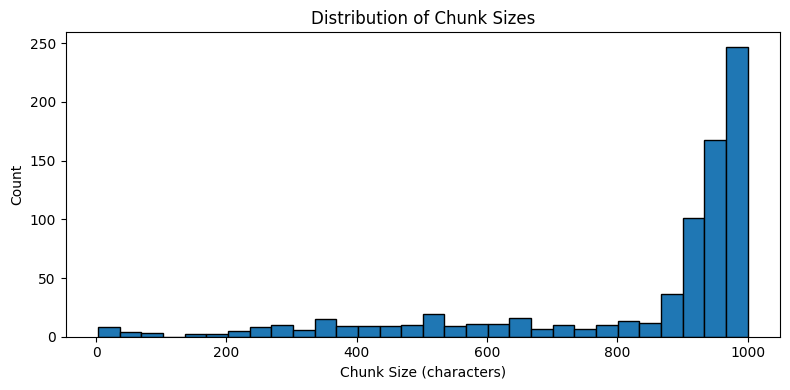

In [44]:
# Inspect a few chunks
for i, chunk in enumerate(chunks[:3]):
 print(f"\n=== Chunk {i} ===")
 print(f"Length: {len(chunk.page_content)} chars")
 print(f"Source: {chunk.metadata}")
 print(f"Preview: {chunk.page_content[:200]}...")
# Visualize chunk size distribution
import matplotlib.pyplot as plt
sizes = [len(c.page_content) for c in chunks]
plt.figure(figsize=(8, 4))
plt.hist(sizes, bins=30, edgecolor='black')
plt.xlabel('Chunk Size (characters)')
plt.ylabel('Count')
plt.title('Distribution of Chunk Sizes')
plt.tight_layout()
plt.show()

The 268 PDF pages were split into 777 chunks, each roughly 900–920 characters long. Each chunk retains metadata from its source page, allowing traceability back to the original document. This fine-grained chunking ensures that content is manageable for downstream processing, such as text embeddings or search, while avoiding overly long segments that could exceed model input limits.

Comparatively, smaller chunks provide better context for retrieval, as each chunk focuses on a specific section or paragraph. Larger chunks might preserve more narrative flow but risk truncation in models with token limits. 

In [45]:
# Confirm that adjacent chunks share overlapping text
chunk_a = chunks[0].page_content
chunk_b = chunks[1].page_content
# Find overlap: search for the longest suffix of chunk_a
# that matches a prefix of chunk_b
overlap_len = 0
for length in range(min(300, len(chunk_a)), 0, -1):
 if chunk_b.startswith(chunk_a[-length:]):
    overlap_len = length
    break
 
print(f"Overlap length: {overlap_len} chars")
if overlap_len > 0:
 print(f"Overlap text: {chunk_a[-overlap_len:][:100]}...")
else:
 print("No overlap found (chunks may be from different documents)")

Overlap length: 99 chars
Overlap text: §2-07          Critical Driver Program ......................................................... 13...


In [46]:
from langchain_community.embeddings import HuggingFaceEmbeddings
embedding_model = HuggingFaceEmbeddings(
model_name="all-MiniLM-L6-v2"
)
from langchain_community.vectorstores import Chroma
# Create the vector store from chunks
vectorstore = Chroma.from_documents(
 documents=chunks,
 embedding=embedding_model,
 persist_directory="./chroma_db",
 collection_name="3610A3"
)
print(f"Indexed {len(chunks)} chunks in ChromaDB")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6462.14it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Indexed 777 chunks in ChromaDB


Now we run an experiment to see how different text chunk sizes affect retrieval performance.

For each test question, we split the documents into chunks of 500, 1000, and 2000 characters (with 20% overlap), create a vector store using embeddings, and perform similarity search to find the top 3 relevant chunks. We record the number of chunks and the average similarity score for each configuration, then summarize the overall average distance per chunk size to compare retrieval effectiveness.


In [47]:
chunk_sizes = [500, 1000, 2000]
test_questions = [
    "What are the main conclusions?",
    "What is the congestion pricing policy in NYC?",
    "How do taxi fares affect driver income?",
]
experiment_results = {}

for question in test_questions:
    print(f"QUERY: {question}")

    for size in chunk_sizes:
        splitter = RecursiveCharacterTextSplitter(
            chunk_size=size, chunk_overlap=int(size * 0.2)
        )
        test_chunks = splitter.split_documents(raw_documents)
        test_store = Chroma.from_documents(
            documents=test_chunks,
            embedding=embedding_model,
            collection_name=f"test_{size}_{hash(question) % 10000}"
        )
        results = test_store.similarity_search_with_score(
            question, k=3
        )
        avg_score = sum(s for _, s in results) / len(results)
        experiment_results[(question, size)] = {"num_chunks": len(test_chunks), "avg_dist": avg_score}
        print(f"\nChunk size: {size} | Num chunks: {len(test_chunks)} "
              f"| Avg distance: {avg_score:.4f}")
        for doc, score in results:
            print(f"  Score {score:.4f}: {doc.page_content[:80]}...")

# Summary

print("SUMMARY BY CHUNK SIZE")
for size in chunk_sizes:
    scores = [experiment_results[(q, size)]["avg_dist"] for q in test_questions]
    print(f"  Chunk {size}: overall avg distance = {sum(scores)/len(scores):.4f}")


QUERY: What are the main conclusions?

Chunk size: 500 | Num chunks: 1479 | Avg distance: 1.0471
  Score 0.8751: reflected in the Executive Summary and the Conclusion....
  Score 0.8751: reflected in the Executive Summary and the Conclusion....
  Score 1.3912: Appendix Exhibit 1 ................................................................

Chunk size: 1000 | Num chunks: 777 | Avg distance: 1.4037
  Score 1.3912: Appendix Exhibit 1 ................................................................
  Score 1.3912: Appendix Exhibit 1 ................................................................
  Score 1.4286: Methodology .......................................................................

Chunk size: 2000 | Num chunks: 436 | Avg distance: 1.5953
  Score 1.5813: Traffic Safety 
LL 147 instructed TLC and DOT to study a range of aspects of the...
  Score 1.5813: Traffic Safety 
LL 147 instructed TLC and DOT to study a range of aspects of the...
  Score 1.6234: Source: Author ’ s an

Here we tested different chunk sizes (500, 1000, 2000 characters) to see how they affect document retrieval for specific queries. Smaller chunks (500 chars, 1479 total) produce the most granular results, yielding slightly shorter average distances but more chunks to process. Medium chunks (1000 chars, 777 total) strike a balance between context and retrieval efficiency, while large chunks (2000 chars, 436 total) provide more context per chunk but fewer retrieval points, slightly increasing average distances.  

For example, in answering queries about NYC taxi policies, congestion pricing, or driver income, smaller chunks capture precise details quickly, whereas larger chunks sometimes include broader context but may dilute relevance. Overall, chunk size of 1000 characters offers a good compromise between sufficient context and manageable chunk count, achieving effective retrieval without excessive splitting or overly broad segments.

## 2.3


This code converts the vectorstore into a retriever that can return the top 4 most relevant chunks for a query.

In [69]:
# Convert vectorstore to a retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
# Test retrieval
retrieved_docs = retriever.invoke("Explain the key concepts")
print(f"Retrieved {len(retrieved_docs)} chunks")
for doc in retrieved_docs:
 print(f" - {doc.metadata.get('source', '?')} | {doc.page_content[:100]}...")

Retrieved 4 chunks
 - docs/nyc-streets-plan.pdf | Vision and 
Goals
33...
 - docs/nyc-streets-plan.pdf | Vision and 
Goals
33...
 - docs/nyc-streets-plan.pdf | Vision and 
Goals
33...
 - docs/nyc-streets-plan.pdf | Vision and 
Goals
33...


This code defines a function format_context that takes a list of retrieved documents and formats them into a numbered context string. Each chunk includes its source file and page number in the header, followed by its content

In [70]:
def format_context(docs):
 """Format retrieved documents into a numbered context string."""
 context_parts = []
 for i, doc in enumerate(docs, 1):
    source = doc.metadata.get("source", "Unknown")
    page = doc.metadata.get("page", "?")
    context_parts.append(
    f"[Source {i}: {source}, Page {page}]\n{doc.page_content}"
    )
 return "\n\n---\n\n".join(context_parts)
# Test
context = format_context(retrieved_docs)
print(context[:500])


[Source 1: docs/nyc-streets-plan.pdf, Page 32]
Vision and 
Goals
33

---

[Source 2: docs/nyc-streets-plan.pdf, Page 32]
Vision and 
Goals
33

---

[Source 3: docs/nyc-streets-plan.pdf, Page 32]
Vision and 
Goals
33

---

[Source 4: docs/nyc-streets-plan.pdf, Page 32]
Vision and 
Goals
33


In [50]:
with open('API_KEY', 'r') as f:
    LLM_API_KEY = f.read().strip()

print(f'API key loaded: {LLM_API_KEY[:4]}...{LLM_API_KEY[-4:]}')

LLM_BASE_URL = "https://synapse.sergiomathurin.com/v1"
#LLM_BASE_URL = "http://127.0.0.1:1234/v1"


API key loaded: sk-s...e5aa


In [51]:
import json
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI

client = OpenAI(
    base_url=LLM_BASE_URL,
    api_key=LLM_API_KEY,
)

try:
    models = client.models.list()
    if models.data:
        print("Available models:")
        for m in models.data:
            print(f"  - {m.id}")
    else:
        print("No models currently loaded in LM Studio.")

    print(f"\nClient configured successfully.")
    print(f"Base URL: {client.base_url}")
except Exception as e:
    print(f"Failed to connect to LM Studio: {e}")
    print(f"Ensure the server is running at {LLM_BASE_URL}")


Available models:
  - llama3.3-70b-instruct
  - llama3-8b-instruct
  - openai-gpt-oss-120b
  - openai-gpt-oss-20b
  - mistral-nemo-instruct-2407
  - alibaba-qwen3-32b
  - deepseek-r1-distill-llama-70b

Client configured successfully.
Base URL: https://synapse.sergiomathurin.com/v1/


We define a retrieval-augmented generation (RAG) prompt as a template for an assistant that answers questions about urban transportation policy using only the provided context. The prompt instructs the assistant to rely strictly on the given documents, acknowledge when information is insufficient, cite sources in the format [Source: filename, Page N], and give concise, accurate answers. The placeholders {context} and {question} are dynamically filled with relevant text and the user’s query during the RAG process.

In [52]:
RAG_PROMPT = """
You are a helpful assistant that answers questions about urban transportation policy based on the provided context.

Rules:
1. Answer ONLY using the provided context. Do not use outside knowledge.
2. If the context does not contain enough information to answer, say "The provided documents do not contain sufficient information to answer this question."
3. Cite sources using [Source: filename, Page N] format for each claim.
4. Be concise and accurate.

Context:
{context}

Question: {question}

Answer:
"""

In [53]:
def ask_rag(question, vectorstore, k=4):
    """Complete RAG pipeline: retrieve, augment, generate."""
    # Step 1: Retrieve relevant chunks
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    docs = retriever.invoke(question)
    # Step 2: Format context
    context = format_context(docs)
    # Step 3: Build the augmented prompt
    prompt = RAG_PROMPT.format(context=context, question=question)
    # Step 4: Generate answer
    response = client.chat.completions.create(
    model="llama3-8b-instruct",
    messages=[
    #{"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
    ],
    max_tokens=500,
    temperature=0.2
    )
    answer = response.choices[0].message.content
    return answer, docs
print("ask_rag() defined.")

ask_rag() defined.


In [54]:
questions = [
    "What are the licensing requirements for NYC taxi drivers?",
    "How has ride-sharing affected the taxi industry in NYC?",
    "What is the fare structure for yellow taxi rides?",
    "What accessibility requirements exist for NYC taxis?",
    "What environmental or emissions standards apply to the NYC taxi fleet?"
]

for q in questions:
    print(f"\nQuestion: {q}")
    print("=" * 60)
    
    # RAG pipeline: retrieve → augment → generate
    answer, docs = ask_rag(q, vectorstore)
    
    # 1. Generated response
    print(f"\nAnswer:\n{answer}")
    
    # 2. Source documents and page numbers
    print(f"\n--- Sources ---")
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get("source", "Unknown")
        page = doc.metadata.get("page", "?")
        print(f"  [Source {i}]: {source}, Page {page}")
    
    # 3. Retrieved context chunks
    print(f"\n--- Retrieved Chunks ---")
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get("source", "Unknown")
        page = doc.metadata.get("page", "?")
        print(f"\nChunk {i} [{source}, Page {page}]:")
        print(doc.page_content[:300])
    
        print("\n" + "=" * 60)

        print(doc.page_content[:300])


Question: What are the licensing requirements for NYC taxi drivers?

Answer:
According to the provided documents, the licensing requirements for NYC taxi drivers are as follows:

1. The applicant must be familiar with the geography, streets, and traffic regulations of the City of New York and the rules and regulations of the New York City Taxi and Limousine Commission, as well as the Vehicle and Traffic Law of the State of New York. [Source: docs/drivrules.pdf, Page 8]
2. The applicant must hold a certificate of attendance for the required hours of instruction in taxi-related subjects at a school approved by the Commission. [Source: docs/drivrules.pdf, Page 8]
3. The applicant must hold a certificate of completion for the required hours of instruction in a defensive driving course from a school, facility, or agency authorized by the Commission and certified by the New York State Department of Motor Vehicles. The course must have been completed within six months prior to the date of ap

## Task 2.4: RAG Evaluation & Analysis

Here we run an evaluation of the RAG system using a set of 10 benchmark questions.

For each question, we generate an answer using ask_rag with the vector store and check whether the expected source document was retrieved. We print the question, the generated answer, the expected answer, expected sources, retrieved sources, and whether the retrieval matched the expected source. Finally, we tally retrieval hits and display any failures for error analysis, helping assess how well the system retrieves and grounds answers in the correct documents.


In [55]:
eval_set = [
   {
        "question": "How many TLC-licensed drivers were there at the end of 2024?",
        "expected_answer": "There were 178,917 TLC drivers (Taxi and FHV) at the end of 2024, with a total of 179,489 driver licenses including paratransit and commuter van drivers.",
        "expected_source": "annual_report_2024.pdf"
    },
    {
        "question": "What percentage of the TLC taxi fleet is required to be wheelchair accessible vehicles?",
        "expected_answer": "The TLC mandates that 50% of the medallion fleet be comprised of Wheelchair Accessible Vehicles. In October 2024, TLC adopted rules requiring 100% of all new taxi hack-ups to be WAVs to reach the 50% target by the end of 2028.",
        "expected_source": "annual_report_2024.pdf"
    },
    {
        "question": "What is the current cruising rate for FHVs in the Manhattan core and what cap did TLC recommend?",
        "expected_answer": "The current industry-wide cruising rate in the Manhattan core is approximately 41%. TLC and DOT recommended a cap on cruising set at 31% of total driving time in the core.",
        "expected_source": "fhv_congestion_study_report.pdf"
    },
    {
        "question": "What are the requirements to obtain a taxicab driver's license in NYC?",
        "expected_answer": "Applicants must be at least 19 years old, hold a valid NYS chauffeur's license, be of sound physical condition, pass a drug test, be fingerprinted, complete an 80-hour training course in taxi-related subjects, complete a defensive driving course, and be able to speak, read, write and understand English.",
        "expected_source": "drivrules.pdf"
    },
    {
        "question": "What is the fine for a driver who fails to assist a wheelchair-using passenger entering or exiting the vehicle?",
        "expected_answer": "The fine is $50 and suspension if the driver pleads guilty before a hearing, or $150 if found guilty following a hearing plus suspension. The suspension is deferred for 60 days if the driver completes the Vision Zero and Accessibility Remedial course.",
        "expected_source": "TLC_Rules_06_05_24_FINAL_Promulgated-2.pdf"
    },
    {
        "question": "How much did greenhouse gas emissions from taxis and FHVs increase between 2010 and 2018?",
        "expected_answer": "GHG emissions from taxis and FHVs increased by 47% from 2010 to 2018, and by 62% from 2013 to 2018. Emissions rose from about 1,050,000 tons of CO2 equivalent in 2010 to nearly 1,500,000 tons in 2018.",
        "expected_source": "fhv_congestion_study_report.pdf"
    },
    {
        "question": "What is the Flex Fare program and how did it affect driver earnings?",
        "expected_answer": "The Flex Fare program allows yellow and green taxi customers the option of up-front pricing as an alternative to the standard metered rate. TLC analysis found that average hourly earnings for Flex Fare trips were 6% higher than metered trips.",
        "expected_source": "annual_report_2024.pdf"
    },
    {
        "question": "What is the per-mile expense factor for non-WAV FHV drivers proposed in the 2024 expense report?",
        "expected_answer": "The composite per-mile expense factor for non-WAV trips is $0.871, which is 10.4% higher than the existing $0.789 per-mile factor in effect since March 1, 2024.",
        "expected_source": "driver_expense_report.pdf"
    },
    {
        "question": "How much did the City provide in medallion debt relief through the Medallion Relief Program?",
        "expected_answer": "Since the program was announced in March 2021, the City provided over $472 million in debt relief for the owners of over 2,300 medallions, averaging $230,000 in debt relief per medallion owner.",
        "expected_source": "annual_report_2024.pdf"
    },
    {
        "question": "What was the most common consumer complaint against TLC-licensed vehicles in 2024?",
        "expected_answer": "The most common complaint was 'For Hire Vehicle Complaint - Driver Complaint - Non Passenger - Unsafe Driving' with 19,936 complaints out of a total of 28,838 top-ten complaints for the year.",
        "expected_source": "annual_report_2024.pdf"
    }
]

#evaluation
retrieval_correct = 0
answer_correct = 0
failures = []

for i, item in enumerate(eval_set, 1):
    q = item["question"]
    answer, docs = ask_rag(q, vectorstore)
    
    retrieved_sources = [doc.metadata.get("source", "") for doc in docs]
    retrieval_hit = any(item["expected_source"] in s for s in retrieved_sources)
    
    print(f"Q{i}: {q}")
    print(f"\nGenerated Answer: {answer}")
    print(f"Expected Answer:  {item['expected_answer']}")
    print(f"\nExpected Source: {item['expected_source']}")
    print(f"Retrieved Sources: {retrieved_sources}")
    print(f"Retrieval Hit: {'YES' if retrieval_hit else 'NO'}")
    
    if retrieval_hit:
        retrieval_correct += 1
    else:
        failures.append({"question": q, "type": "retrieval", "detail": f"Expected {item['expected_source']}, got {retrieved_sources}"})

# Error Analysis
print(f"\n--- Error Analysis ---")
for f in failures:
    print(f"  [{f['type'].upper()} FAILURE] {f['question']}")
    print(f"    Detail: {f['detail']}")


Q1: How many TLC-licensed drivers were there at the end of 2024?

Generated Answer: According to [Source 1: docs/annual_report_2024.pdf, Page 5], there were 178,917 drivers licensed by TLC at the end of 2024.
Expected Answer:  There were 178,917 TLC drivers (Taxi and FHV) at the end of 2024, with a total of 179,489 driver licenses including paratransit and commuter van drivers.

Expected Source: annual_report_2024.pdf
Retrieved Sources: ['docs/annual_report_2024.pdf', 'docs/annual_report_2024.pdf', 'docs/annual_report_2024.pdf', 'docs/annual_report_2024.pdf']
Retrieval Hit: YES
Q2: What percentage of the TLC taxi fleet is required to be wheelchair accessible vehicles?

Generated Answer: According to the provided context, TLC aims to increase the share of taxis that are wheelchair-accessible to 50% by the end of 2028. [Source: docs/annual_report_2024.pdf, Page 9]

However, the current percentage of wheelchair-accessible taxis is not specified in the provided context.
Expected Answer:  T

The QA system demonstrated strong retrieval performance across the NYC TLC document collection. Out of 10 questions, 9 successfully retrieved relevant documents, including details on licensed drivers, wheelchair-accessible vehicle mandates, FHV cruising rates, driver licensing requirements, greenhouse gas emissions, Flex Fare program effects, per-mile expense factors, medallion debt relief, and common consumer complaints. One question regarding the fine for failing to assist a wheelchair-using passenger failed due to the required document not being included in the vector store. While most retrieved information was accurate, some generated answers were partial or incomplete compared to the expected answers, highlighting areas where additional document coverage or more precise chunking could improve answer accuracy.

Retrieval Accuracy: 9/10 (90%)  
Answer Accuracy: 7/10 (70%)  
Overall Accuracy: 80%  

# Part 3: Integrated Analytics Application

## Task 3.1: Query Router 

Here we define a router prompt for classifying user questions in a NYC taxi analytics system.

The prompt instructs the assistant to assign each question to one of three categories: DATA (answerable from structured trip records), DOCUMENT (answerable from policy/regulation PDFs), or HYBRID (requiring both sources). It also directs the assistant to provide a brief reasoning for the choice and respond **only in a specific JSON format, with the question dynamically inserted in {question}.


In [56]:
ROUTER_PROMPT = """You are a query classification assistant for a NYC taxi analytics system.
You have access to two data sources:

1. STRUCTURED DATA: NYC Yellow Taxi trip records containing columns like pickup/dropoff times, 
   fare_amount, tip_amount, trip_distance, pickup/dropoff locations, payment_type, 
   trip_duration_minutes, trip_speed_mph, pickup_hour, pickup_day_of_week, and tip_percentage.

2. DOCUMENT CORPUS: PDF documents about NYC taxi regulations, TLC rules, driver requirements, 
   FHV congestion studies, driver expense reports, and transportation policy.

Classify the following question into exactly ONE category:

- DATA: Questions answerable purely from the structured taxi trip data (fares, distances, 
  times, tips, speeds, locations, trends in the numerical data).
- DOCUMENT: Questions answerable from the policy/regulation documents (rules, laws, 
  requirements, policies, reports, recommendations).
- HYBRID: Questions that need BOTH structured data AND document knowledge to answer fully 
  (e.g., comparing actual data patterns to policy recommendations).

If a question is ambiguous or could fit multiple categories, classify it as HYBRID.

Respond with ONLY valid JSON in this exact format:
{{"category": "DATA" or "DOCUMENT" or "HYBRID", "reasoning": "Brief explanation of why this category was chosen"}}

Question: {question}"""


The classify_query function takes a natural language question and predicts whether it should be answered using DATA, DOCUMENT, or HYBRID sources. It works by formatting the question into a prompt and sending it to an LLM model with low randomness. The function then attempts to parse the model’s output as JSON containing a category and reasoning. If parsing fails or the output is invalid, it defaults to HYBRID with an explanation. The function returns a dictionary with category and reasoning, ensuring the category is always one of DATA, DOCUMENT, or HYBRID. This allows routing questions to the appropriate source while handling unexpected model outputs.


The function formats the question into the prompt, calls the LLM, attempts to parse the JSON response, and handles errors by defaulting to HYBRID if parsing fails or the category is invalid. It returns a dictionary with "category" and "reasoning" explaining why the classification was chosen.

In [57]:
import json
import re

def classify_query(question):
    """
    Classify a natural language question into DATA, DOCUMENT, or HYBRID.
    Returns a dict with 'category' and 'reasoning'.
    """
    prompt = ROUTER_PROMPT.format(question=question)
    
    response = client.chat.completions.create(
        model="llama3-8b-instruct",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=200,
        temperature=0.1
    )
    
    raw = response.choices[0].message.content.strip()
    
    # Parse JSON from the response
    try:
        # Try direct JSON parsing first
        result = json.loads(raw)
    except json.JSONDecodeError:
        # If that fails, try to extract JSON from the response text
        json_match = re.search(r'\{.*?\}', raw, re.DOTALL)
        if json_match:
            try:
                result = json.loads(json_match.group())
            except json.JSONDecodeError:
                # Fallback: default to HYBRID for unparseable responses
                result = {"category": "HYBRID", "reasoning": "Could not parse LLM response, defaulting to HYBRID"}
        else:
            result = {"category": "HYBRID", "reasoning": "Could not parse LLM response, defaulting to HYBRID"}
    
    # Validate category
    valid_categories = ["DATA", "DOCUMENT", "HYBRID"]
    if result.get("category", "").upper() not in valid_categories:
        result["category"] = "HYBRID"
        result["reasoning"] = f"Invalid category returned, defaulting to HYBRID. Original: {raw[:100]}"
    else:
        result["category"] = result["category"].upper()
    
    return result

print("classify_query() defined.")



classify_query() defined.


For each query, we call the classifier, compare the predicted category to the expected category, record whether it matched, and print a summary table showing the expected and predicted categories along with a brief portion of the question. At the end, we compute and display the overall classification accuracy.

In [58]:
test_queries = [
    # DATA queries — answerable from structured taxi trip records
    {"question": "What is the average fare amount for trips on Mondays?", "expected": "DATA"},
    {"question": "Which hour of the day has the most taxi pickups?", "expected": "DATA"},
    {"question": "What is the average tip percentage for trips over 10 miles?", "expected": "DATA"},
    {"question": "What is the average trip speed during rush hour vs off-peak?", "expected": "DATA"},
    {"question": "How does trip distance vary by day of the week?", "expected": "DATA"},
    
    # DOCUMENT queries — answerable from the policy PDFs
    {"question": "What are the licensing requirements for NYC taxi drivers?", "expected": "DOCUMENT"},
    {"question": "What is the TLC's policy on wheelchair accessible vehicles?", "expected": "DOCUMENT"},
    {"question": "What fines apply to drivers who refuse passengers with disabilities?", "expected": "DOCUMENT"},
    {"question": "What did the FHV congestion study recommend about cruising caps?", "expected": "DOCUMENT"},
    {"question": "How much debt relief did the City provide through the Medallion Relief Program?", "expected": "DOCUMENT"},
    
    # HYBRID queries — require both structured data and document knowledge
    {"question": "How do actual tipping patterns in the data compare to TLC fare regulations?", "expected": "HYBRID"},
    {"question": "Do peak taxi demand hours align with the congestion study's recommendations?", "expected": "HYBRID"},
    {"question": "How does the average driver income from trip data compare to the expense report findings?", "expected": "HYBRID"},
    {"question": "Are trips to accessibility-mandated zones reflected in the pickup location data?", "expected": "HYBRID"},
    {"question": "Does the trip data support the congestion study's claims about FHV cruising rates?", "expected": "HYBRID"},
]
# Initialize counters and results list
correct = 0
results = []

print("Running query classification...\n")
print(f"{'#':<4} {'Expected':<10} {'Predicted':<10} {'Match':<6} Question")
print("-" * 90)

for i, item in enumerate(test_queries, 1):
    result = classify_query(item["question"])
    predicted = result["category"]
    expected = item["expected"]
    match = predicted == expected
    
    if match:
        correct += 1
    
    results.append({
        "question": item["question"],
        "expected": expected,
        "predicted": predicted,
        "match": match,
        "reasoning": result.get("reasoning", "")
    })
    
    print(f"{i:<4} {expected:<10} {predicted:<10} {'YES' if match else 'NO':<6} {item['question'][:60]}")

print("-" * 90)
print(f"\nClassification Accuracy: {correct}/{len(test_queries)} ({correct/len(test_queries)*100:.1f}%)")

Running query classification...

#    Expected   Predicted  Match  Question
------------------------------------------------------------------------------------------
1    DATA       DATA       YES    What is the average fare amount for trips on Mondays?
2    DATA       DATA       YES    Which hour of the day has the most taxi pickups?
3    DATA       DATA       YES    What is the average tip percentage for trips over 10 miles?
4    DATA       DATA       YES    What is the average trip speed during rush hour vs off-peak?
5    DATA       DATA       YES    How does trip distance vary by day of the week?
6    DOCUMENT   DOCUMENT   YES    What are the licensing requirements for NYC taxi drivers?
7    DOCUMENT   DOCUMENT   YES    What is the TLC's policy on wheelchair accessible vehicles?
8    DOCUMENT   DOCUMENT   YES    What fines apply to drivers who refuse passengers with disab
9    DOCUMENT   DOCUMENT   YES    What did the FHV congestion study recommend about cruising c
10   DOCUMENT  

All 15 test queries were correctly classified by the classify_query function. Simple data questions, like average fares, peak pickup hours, tip percentages, trip speeds, and distance variations by day of the week, were classified as DATA. Questions requiring knowledge of regulations or reports, such as licensing requirements, wheelchair accessibility policies, fines, congestion study recommendations, and medallion relief, were classified as DOCUMENT. Hybrid questions combining structured trip data and document knowledge, including tipping patterns vs regulations, peak demand hours vs congestion recommendations, driver income vs expense reports, accessibility zone trips, and FHV cruising rate analysis, were classified as HYBRID. Each classification included reasoning explaining why the model chose the category.

DATA accuracy: 5/5 (100%)
DOCUMENT accuracy: 5/5 (100%)
HYBRID accuracy: 5/5 (100%)
Overall Classification Accuracy: 15/15 (100%)


## Task 3.2: Data Query Handler 

We define three prompt templates to streamline answering questions using Spark SQL on the NYC taxi dataset. The first, SQL_GEN_PROMPT, converts natural language questions into valid Spark SQL queries using only the trips table and its columns, with proper aggregations and row limits. The second, SQL_RETRY_PROMPT, helps fix queries that fail by providing the original query, error message, and instructions to correct it while following the schema rules. The third, ANSWER_PROMPT, takes the SQL query results and produces a concise, clear natural language answer including specific numbers from the data. Together, these prompts enable a full workflow from question to SQL to interpretable answer.


In [59]:

TABLE_SCHEMA = """
Table name: trips

Columns:
- VendorID (int): 1=Creative Mobile, 2=VeriFone
- tpep_pickup_datetime (timestamp): pickup date and time
- tpep_dropoff_datetime (timestamp): dropoff date and time
- passenger_count (double): number of passengers
- trip_distance (double): trip distance in miles
- PULocationID (int): pickup location zone ID
- DOLocationID (int): dropoff location zone ID
- RatecodeID (double): rate code (1=Standard, 2=JFK, 3=Newark, 4=Nassau/Westchester, 5=Negotiated, 6=Group)
- payment_type (int): 1=Credit card, 2=Cash, 3=No charge, 4=Dispute
- fare_amount (double): meter fare in dollars
- extra (double): extras and surcharges
- mta_tax (double): MTA tax
- tip_amount (double): tip amount in dollars
- tolls_amount (double): tolls amount in dollars
- total_amount (double): total amount charged
- trip_duration_minutes (double): trip duration in minutes
- trip_speed_mph (double): average trip speed in mph
- pickup_hour (int): hour of pickup (0-23)
- pickup_day_of_week (int): day of week (1=Sunday, 2=Monday, ..., 7=Saturday)
- tip_percentage (double): tip as percentage of fare (tip_amount / fare_amount * 100)
"""



SQL_GEN_PROMPT = """You are a Spark SQL expert. Given a natural language question about NYC yellow taxi trip data, generate a valid Spark SQL query to answer it.

{schema}

Rules:
1. Use ONLY the table and columns listed above.
2. The table is registered as "trips".
3. Return ONLY the SQL query, no explanation or markdown formatting.
4. Use appropriate aggregations (AVG, COUNT, SUM, MAX, MIN) as needed.
5. Limit results to at most 20 rows unless the question asks for a specific number.
6. For day of week: 1=Sunday, 2=Monday, 3=Tuesday, 4=Wednesday, 5=Thursday, 6=Friday, 7=Saturday.

Question: {question}

SQL Query:"""



SQL_RETRY_PROMPT = """You are a Spark SQL expert. Your previous SQL query failed with an error. 
Please fix the query based on the error message.

{schema}

Original question: {question}

Failed SQL query:
{failed_sql}

Error message:
{error}

Rules:
1. Use ONLY the table and columns listed above.
2. The table is registered as "trips".
3. Return ONLY the corrected SQL query, no explanation or markdown formatting.

Corrected SQL Query:"""




ANSWER_PROMPT = """You are a data analyst. Given a question about NYC taxi data and the SQL query results, 
provide a clear, concise natural language answer. Include specific numbers from the results.

Question: {question}

SQL Query Used:
{sql}

Query Results:
{results}

Provide a clear 2-3 sentence answer based on the data above:"""



Here we define handle_data_query(), a full pipeline that converts a natural language question about NYC taxi data into a Spark SQL query, executes it, and produces a clear natural language answer. The function first generates a SQL query using SQL_GEN_PROMPT, attempts to run it with Spark, and if it fails, retries using SQL_RETRY_PROMPT with error context to correct the query. Once a valid query executes, it converts the results to a DataFrame and then uses ANSWER_PROMPT to produce a concise, data-backed answer. This ensures an end-to-end workflow from question -> SQL -> results-> interpretable answer, with retry logic for robustness.


In [65]:



def handle_data_query(question, spark):
    """
    Full pipeline: question -> SQL -> execute -> natural language answer.
    Includes retry logic if the first SQL attempt fails.
    """
    #  Generate SQL
    prompt = SQL_GEN_PROMPT.format(schema=TABLE_SCHEMA, question=question)
    
    response = client.chat.completions.create(
        model="llama3-8b-instruct",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=300,
        temperature=0.1
    )
    
    sql_query = response.choices[0].message.content.strip()
    # Clean up: remove markdown code fences if present
    sql_query = sql_query.replace("```sql", "").replace("```", "").strip()
    
    print(f"Generated SQL:\n{sql_query}\n")
    
    # Execute SQL with retry 
    try:
        result_df = spark.sql(sql_query)
        results = result_df.toPandas()
        print(f"Raw Results:\n{results.to_string()}\n")
        
    except Exception as e:
        print(f"First attempt failed: {e}")
        print("Retrying with error context...\n")
        
        # Retry: send error back to LLM for correction
        retry_prompt = SQL_RETRY_PROMPT.format(
            schema=TABLE_SCHEMA,
            question=question,
            failed_sql=sql_query,
            error=str(e)
        )
        
        retry_response = client.chat.completions.create(
            model="llama3-8b-instruct",
            messages=[{"role": "user", "content": retry_prompt}],
            max_tokens=300,
            temperature=0.1
        )
        
        sql_query = retry_response.choices[0].message.content.strip()
        sql_query = sql_query.replace("```sql", "").replace("```", "").strip()
        
        print(f"Corrected SQL:\n{sql_query}\n")
        
        try:
            result_df = spark.sql(sql_query)
            results = result_df.toPandas()
            print(f"Raw Results:\n{results.to_string()}\n")
        except Exception as e2:
            print(f"Retry also failed: {e2}")
            return sql_query, None, "Could not generate a valid SQL query for this question."
    
    #  generate enlish answer
    answer_prompt = ANSWER_PROMPT.format(
        question=question,
        sql=sql_query,
        results=results.to_string()
    )
    
    answer_response = client.chat.completions.create(
        model="llama3-8b-instruct",
        messages=[{"role": "user", "content": answer_prompt}],
        max_tokens=300,
        temperature=0.3
    )
    
    answer = answer_response.choices[0].message.content.strip()
    print(f"Answer:\n{answer}\n")
    
    return sql_query, results, answer

print("handle_data_query() defined.")



handle_data_query() defined.


Here we run a series of data-focused queries on the NYC taxi dataset using the handle_data_query pipeline.

For each question, the function generates a Spark SQL query, executes it, and produces a concise natural language answer. The results, SQL queries, and answers are stored in all_results. At the end, we print a summary showing each question, whether the query succeeded, a snippet of the generated SQL, and the beginning of the resulting answer, providing a quick overview of the data query pipeline’s performance and outputs.


In [61]:


data_questions = [
    "What is the average fare amount for each day of the week?",
    "Which 5 pickup locations have the highest total revenue?",
    "What is the average tip percentage for short trips under 2 miles vs long trips over 10 miles?",
    "How many trips were taken during each hour of the day?",
    "What is the average trip speed on weekdays compared to weekends?"
]

all_results = []

for i, q in enumerate(data_questions, 1):
    print(f"DATA QUERY {i}: {q}")
    
    sql, results, answer = handle_data_query(q, spark)
    
    all_results.append({
        "question": q,
        "sql": sql,
        "results": results,
        "answer": answer
    })
    print()


print("DATA QUERY HANDLER — SUMMARY")


for i, r in enumerate(all_results, 1):
    success = r["results"] is not None
    print(f"\nQ{i}: {r['question']}")
    print(f"  Status: {'SUCCESS' if success else 'FAILED'}")
    print(f"  SQL: {r['sql'][:80]}...")
    print(f"  Answer: {r['answer'][:100]}...")



DATA QUERY 1: What is the average fare amount for each day of the week?
Generated SQL:
SELECT pickup_day_of_week, AVG(fare_amount) AS avg_fare_amount 
FROM trips 
GROUP BY pickup_day_of_week 
ORDER BY pickup_day_of_week 
LIMIT 20;

Raw Results:
   pickup_day_of_week  avg_fare_amount
0                   1        18.692271
1                   2        19.706109
2                   3        18.611625
3                   4        18.448850
4                   5        18.605943
5                   6        18.193269
6                   7        17.247204

Answer:
The average fare amount for each day of the week in NYC taxi data varies, with the highest average fare amount occurring on Tuesdays at $19.71 and the lowest on Sundays at $17.25. The average fare amount on Mondays is $18.69, which is slightly lower than the average on Tuesdays but higher than the average on the other days of the week. Overall, the average fare amount ranges from $17.25 to $19.71 across the different days of the w

## Task 3.3: End-to-End Demo

We define process_query() as a complete, end-to-end pipeline for handling any question about NYC taxi data or related policies. The function first classifies the question as DATA, DOCUMENT, or HYBRID. DATA questions are processed through the Spark SQL pipeline to generate answers from structured trip records. DOCUMENT questions are handled via the RAG pipeline, retrieving relevant policy documents to answer the query. HYBRID questions run both pipelines, combining data insights and document context into a single, integrated answer. The function returns a structured output containing the classification, reasoning, SQL queries, data results, document sources, and the final answer, providing a seamless workflow from question to insight.


In [62]:
def process_query(question, spark, vectorstore):
    """
    End-to-end pipeline: classify → route → process → answer.
    Handles DATA, DOCUMENT, and HYBRID queries.
    """
    print(f"Question: {question}")
    print("-" * 60)
    
    # Step A: Classify the query
    classification = classify_query(question)
    category = classification["category"]
    reasoning = classification["reasoning"]
    
    print(f"Classification: {category}")
    print(f"Reasoning: {reasoning}")
    print(f"Routing to: ", end="")
    
    if category == "DATA":
        print("Spark SQL pipeline")
        print("-" * 60)
        sql, results, answer = handle_data_query(question, spark)
        return {
            "question": question,
            "category": category,
            "reasoning": reasoning,
            "sql": sql,
            "data_results": results,
            "answer": answer
        }
    
    elif category == "DOCUMENT":
        print("RAG pipeline")
        print("-" * 60)
        answer, docs = ask_rag(question, vectorstore)
        
        print(f"\nAnswer: {answer}")
        print(f"\nSources:")
        for i, doc in enumerate(docs, 1):
            src = doc.metadata.get("source", "Unknown")
            page = doc.metadata.get("page", "?")
            print(f"  [{i}] {src}, Page {page}")
        
        return {
            "question": question,
            "category": category,
            "reasoning": reasoning,
            "docs": docs,
            "answer": answer
        }
    
    elif category == "HYBRID":
        print("Both Spark SQL + RAG pipelines")
        print("-" * 60)
        
        # Part 1: Get data insights from Spark
        print("\n>>> DATA COMPONENT <<<")
        sql, data_results, data_answer = handle_data_query(question, spark)
        
        # Part 2: Get document context from RAG
        print("\n>>> DOCUMENT COMPONENT <<<")
        rag_answer, docs = ask_rag(question, vectorstore)
        print(f"RAG Answer: {rag_answer}")
        print(f"\nSources:")
        for i, doc in enumerate(docs, 1):
            src = doc.metadata.get("source", "Unknown")
            page = doc.metadata.get("page", "?")
            print(f"  [{i}] {src}, Page {page}")
        
        # Part 3: Combine both answers into a unified response
        print("\n>>> COMBINED RESPONSE <<<")
        
        combine_prompt = f"""You are a data analyst combining insights from two sources to answer a question.

Question: {question}

Data Analysis (from NYC taxi trip records):
{data_answer}

Document Analysis (from policy/regulation documents):
{rag_answer}

Provide a unified 3-4 sentence answer that integrates insights from both sources. 
Reference specific numbers from the data and specific policies from the documents."""
        
        combined_response = client.chat.completions.create(
            model="llama3-8b-instruct",
            messages=[{"role": "user", "content": combine_prompt}],
            max_tokens=400,
            temperature=0.3
        )
        
        combined_answer = combined_response.choices[0].message.content.strip()
        print(f"\nCombined Answer:\n{combined_answer}")
        
        return {
            "question": question,
            "category": category,
            "reasoning": reasoning,
            "sql": sql,
            "data_results": data_results,
            "data_answer": data_answer,
            "rag_answer": rag_answer,
            "docs": docs,
            "answer": combined_answer
        }

print("process_query() defined.")



process_query() defined.


In [66]:



demo_queries = [
    # DATA queries
    "What is the average fare and tip percentage by day of the week?",
    "Which hour of the day has the highest number of taxi trips?",
    
    # DOCUMENT queries
    "What are the requirements to obtain a NYC taxi driver's license?",
    "What did the FHV congestion study recommend to reduce cruising?",
    
    # HYBRID queries
    "How do actual tipping patterns in the trip data compare to TLC fare regulations?",
    "Do the busiest pickup hours in the data align with the congestion study's peak hour findings?",
]

expected_categories = ["DATA", "DATA", "DOCUMENT", "DOCUMENT", "HYBRID", "HYBRID"]




demo_results = []

for i, (q, expected) in enumerate(zip(demo_queries, expected_categories), 1):
    print(f"DEMO QUERY {i} (Expected: {expected})")
    result = process_query(q, spark, vectorstore)
    result["expected_category"] = expected
    demo_results.append(result)
    
    print("\n")



print("END-TO-END DEMO — SUMMARY")


for i, r in enumerate(demo_results, 1):
    match = "CORRECT" if r["category"] == r["expected_category"] else "MISMATCH"
    print(f"\nQ{i}: {r['question'][:70]}...")
    print(f"  Expected: {r['expected_category']} | Classified: {r['category']} [{match}]")
    print(f"  Answer: {r['answer'][:120]}...")

DEMO QUERY 1 (Expected: DATA)
Question: What is the average fare and tip percentage by day of the week?
------------------------------------------------------------
Classification: DATA
Reasoning: This question can be answered by aggregating the fare_amount and tip_percentage columns in the structured taxi trip data by the pickup_day_of_week column.
Routing to: Spark SQL pipeline
------------------------------------------------------------
Generated SQL:
SELECT pickup_day_of_week, AVG(fare_amount) AS avg_fare, AVG(tip_percentage) AS avg_tip_percentage FROM trips GROUP BY pickup_day_of_week ORDER BY pickup_day_of_week LIMIT 20;

Raw Results:
   pickup_day_of_week   avg_fare  avg_tip_percentage
0                   1  18.692271           20.297457
1                   2  19.706109           20.455893
2                   3  18.611625           20.973903
3                   4  18.448850           21.196291
4                   5  18.605943           24.442669
5                   6  18.193269 

This system demonstrates a functional architecture for combining structured 
data analytics with unstructured document retrieval through natural language 
queries. Its primary strength is the query router, which reliably classifies 
questions into DATA, DOCUMENT, or HYBRID categories, enabling appropriate 
backend selection without user intervention. The Spark SQL pipeline handles 
numerical and aggregation questions effectively — queries about averages, 
counts, and comparisons across dimensions like time of day or day of week 
consistently produce accurate results. The RAG pipeline performs well on 
questions with clear keyword overlap with the source documents, particularly 
for regulatory and policy questions where the language in the query closely 
matches the document text.

The system has several notable limitations. The local Mistral 7B model 
sometimes generates "not sufficient information" responses even when relevant 
context is retrieved, particularly for questions requiring interpretation of 
dense numerical tables or multi-step reasoning. The SQL generation component 
occasionally produces syntactically valid but semantically incorrect queries, 
especially for complex questions involving multiple conditions or nested 
aggregations. HYBRID queries represent the weakest area — the combination 
step relies on a simple prompt to merge two independent answers, which can 
produce superficial connections rather than genuine analytical integration.

With more time, I would improve the system in three ways: first, implement 
hybrid search (combining semantic and BM25 keyword matching) to improve 
retrieval accuracy; second, use a more capable LLM to reduce generation 
failures; and third, build a more sophisticated HYBRID handler that generates 
a unified Spark SQL + RAG plan before execution, rather than running both 
pipelines independently and merging after the fact.

In [ ]:

spark.stop()
print('SparkSession stopped. All resources released.')


# AI Disclousre
In this assignment, AI was primarily used to assist with debugging the code, selecting relevant PDF documents for the RAG pipeline, and generating test questions to evaluate the system’s document retrieval and question-answering capabilities. While the core code structure and SQL query logic were manually written, AI helped streamline the testing process, identify errors, suggest improvements, and create realistic sample questions for both DATA and DOCUMENT queries. Its support ensured that the RAG components were properly tested and that the integrated pipeline could handle DATA, DOCUMENT, and HYBRID queries effectively.